In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Cleaned_dataset.csv')

In [ ]:
df.head()

,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,3.8,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,3.6,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,3.9,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,3.9,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,4.4,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [ ]:
x = df.drop(['Time_taken_min','Average_Speed_kmph'],axis = 1)
y = df['Time_taken_min']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,
                                                 y,
                                                 test_size= 0.2,
                                                 random_state=42)


In [ ]:
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

# Fit on train
x_train[['Day_of_Week']] = encoder.fit_transform(
    x_train[['Day_of_Week']]
)

# Transform test
x_test[['Day_of_Week']] = encoder.transform(
    x_test[['Day_of_Week']]
)

In [ ]:
num_cols = x_train.select_dtypes(include = ['int64','float64']).columns
cat_cols = x_train.select_dtypes(include = ['object']).columns

print('Numerical:',list(num_cols))
print('Categorical:',list(cat_cols))

Numerical: ['Order_Hour', 'Day_of_Week', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating', 'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals']
Categorical: ['Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load', 'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority']


In [ ]:
nominal_col = ['Day_of_Week','Weather','Pickup_Zone','Dropoff_Zone','Vehicle_Type','Cuisine_Type']
ordinal_col = ['Restaurant_Load','Delivery_Distance_Category','Traffic_Level','Delivery_Priority']

In [ ]:
num_pipeline=Pipeline([
        ('imputer',SimpleImputer(strategy='mean')),
        ('scalar',StandardScaler())
    ])

In [ ]:
nominal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scalar',OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
ordinal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scalar',OrdinalEncoder(
        categories=[
            ["Low", "Medium", "High"],
            ["Short", "Medium", "Long"],
            ["Low", "Moderate", "High", "Severe"],
            ["Normal", "Priority", "VIP"]
        ])
    )
])

In [ ]:
preprocessor=ColumnTransformer(
    transformers=(
        ('num',num_pipeline,num_cols),
        ('nominal',nominal_pipeline,nominal_col),
        ('ordinal',ordinal_pipeline,ordinal_col)
    ),remainder='drop'
)

In [ ]:
model = DecisionTreeRegressor()

In [ ]:
pipe = Pipeline(
    [('Preprocessor',preprocessor),
    ('model',model)]
)

In [ ]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=(('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  Index(['Order_Hour', 'Day_of_Week', 'Is_Weekend', 'Is_Festival',
       'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating',
       'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km',
       'Number_of_Signals'],
      dtype='...
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scalar',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High'],
                                                                                              ['Short',
                                                                                               'Medium',
                                                                                               'Long'],
                                                                                              ['Low',
                                                                                               'Moderate',
                                                                                               'High',
                                                                                               'Severe'],
                                                                                              ['Normal',
                                                                                               'Priority',
                                                                                               'VIP']]))]),
                                                  ['Restaurant_Load',
                                                   'Delivery_Distance_Category',
                                                   'Traffic_Level',
                                                   'Delivery_Priority'])))),
                ('model', DecisionTreeRegressor())])

In [ ]:
preprocessor.get_feature_names_out()


array(['num__Order_Hour', 'num__Day_of_Week', 'num__Is_Weekend',
       'num__Is_Festival', 'num__Rider_Experience_Years',
       'num__Rider_Rating', 'num__Restaurant_Rating', 'num__Order_Items',
       'num__Preparation_Time_Min', 'num__Road_Distance_km',
       'num__Number_of_Signals', 'nominal__Day_of_Week_0.0',
       'nominal__Day_of_Week_1.0', 'nominal__Day_of_Week_2.0',
       'nominal__Day_of_Week_3.0', 'nominal__Day_of_Week_4.0',
       'nominal__Day_of_Week_5.0', 'nominal__Day_of_Week_6.0',
       'nominal__Weather_Clear', 'nominal__Weather_Cloudy',
       'nominal__Weather_Fog', 'nominal__Weather_Rain',
       'nominal__Weather_Storm', 'nominal__Pickup_Zone_CBD',
       'nominal__Pickup_Zone_Commercial',
       'nominal__Pickup_Zone_Industrial',
       'nominal__Pickup_Zone_Residential',
       'nominal__Pickup_Zone_Suburban', 'nominal__Dropoff_Zone_CBD',
       'nominal__Dropoff_Zone_Commercial',
       'nominal__Dropoff_Zone_Industrial',
       'nominal__Dropoff_Zone_Res

In [ ]:
y_pred=pipe.predict(x_test)

In [ ]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2score=r2_score(y_test,y_pred)

In [ ]:
print(mae)
print(rmse)
print(r2score)

4.4549
6.0598267301961695
0.9710907441755461


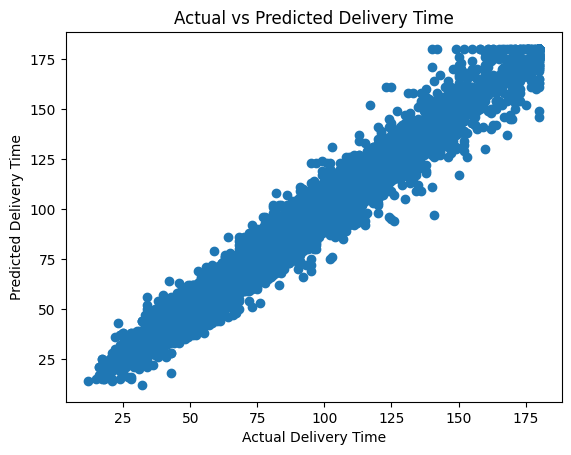

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

In [ ]:
residual=y_test-y_pred

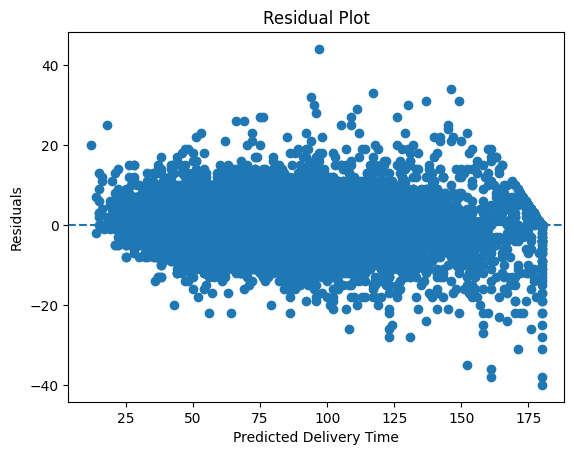

In [ ]:
plt.scatter(y_pred, residual)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Delivery Time")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [ ]:
param_grid = {
    'model__criterion': [
        'squared_error',
        'friedman_mse',
        'absolute_error'
    ],

    'model__max_depth': [
        3, 5, 10, 15, None
    ],

    'model__min_samples_split': [
        2, 5, 10, 20
    ],

    'model__min_samples_leaf': [
        1, 2, 5, 10
    ],

    'model__max_features': [
        None, 'sqrt', 'log2'
    ]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search.fit(x_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("Best CV Score:")
print(random_search.best_score_)

Best Parameters:
{'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 15, 'model__criterion': 'friedman_mse'}
Best CV Score:
0.971689858820224


In [ ]:
best_model = random_search.best_estimator_

print("Best Model:")
print(best_model)

Best Model:
Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=(('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  Index(['Order_Hour', 'Day_of_Week', 'Is_Weekend', 'Is_Festival',
       'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating',
       'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km',
       'Number_of_Signals'],
      dtype='...
                                                                  ('scalar',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                              

In [ ]:
y_pred_tuned = best_model.predict(x_test)

In [ ]:
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

mse_tuned = mean_squared_error(y_test, y_pred_tuned)

rmse_tuned = np.sqrt(mse_tuned)

r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Decision Tree Results")
print("---------------------------")
print("MAE :", mae_tuned)
print("MSE :", mse_tuned)
print("RMSE:", rmse_tuned)
print("R2  :", r2_tuned)

Tuned Decision Tree Results
---------------------------
MAE : 4.100174026005577
MSE : 31.277261428332743
RMSE: 5.592607748477694
R2  : 0.9753767587892652


In [ ]:
print("Baseline vs Tuned")

print("\nMAE")
print("Baseline:", mae)
print("Tuned   :", mae_tuned)

print("\nRMSE")
print("Baseline:", rmse)
print("Tuned   :", rmse_tuned)

print("\nR2 Score")
print("Baseline:", r2score)
print("Tuned   :", r2_tuned)

Baseline vs Tuned

MAE
Baseline: 4.4549
Tuned   : 4.100174026005577

RMSE
Baseline: 6.0598267301961695
Tuned   : 5.592607748477694

R2 Score
Baseline: 0.9710907441755461
Tuned   : 0.9753767587892652


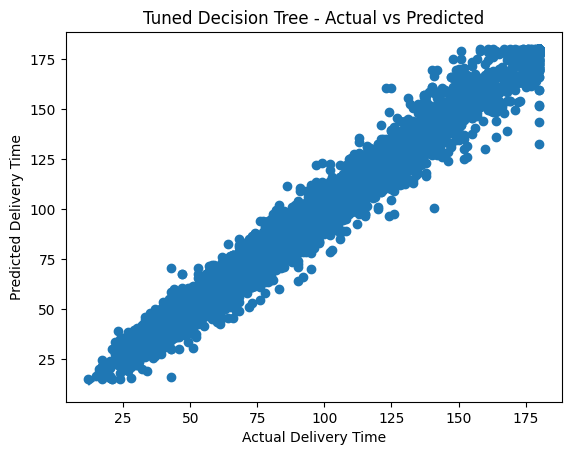

In [ ]:
plt.scatter(y_test, y_pred_tuned)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Tuned Decision Tree - Actual vs Predicted")

plt.show()

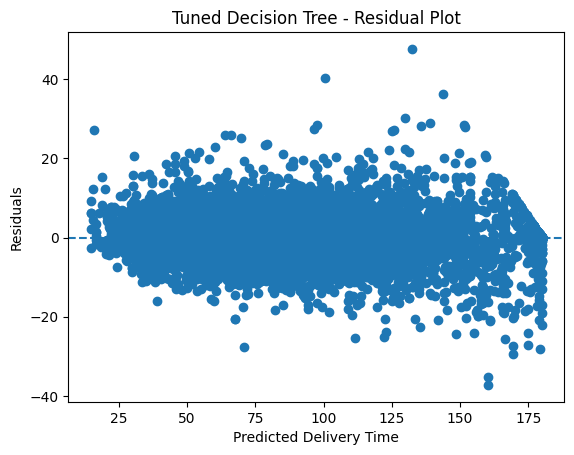

In [ ]:
residual_tuned = y_test - y_pred_tuned

plt.scatter(y_pred_tuned, residual_tuned)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Delivery Time")
plt.ylabel("Residuals")
plt.title("Tuned Decision Tree - Residual Plot")

plt.show()

- I got a good result from the Decision Tree model.
- After tuning the model, the R² score improved to 0.9754.
- The MAE is 4.10 minutes, so the prediction error is around 4 minutes on average.
- The RMSE is 5.59 minutes, which shows that the model has relatively low prediction error.
- After hyperparameter tuning, the model performed better than the basic Decision Tree.
- From this, I can say that the Decision Tree is able to capture the relationship between the different delivery features and delivery time well.
- Overall, Decision Tree gave a strong performance on my dataset and is a good model to compare with the other models.